# Exploratory Data Analysis (EDA) – Spotify Dataset


In this EDA we are exploring and analyzing spotify dataset.
We start by importing important libraries which we are going to use in this.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Here we imported three libraries.
- Numpy - It is used for performing arithmetic operation in dataset (Remember we use perform calculation first by converting part of dataset into numpy array)
- Pandas - It is a library used to efficiently store, manipulate, analyze, and clean structured data.
- Matplotlib - It is used for ploting graph.

## Examine the datastructure

In [2]:
# Loading data into dataFrame
df = pd.read_csv("dataset.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
# Inspecting Columns
print(df.columns)

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')


In [4]:
# Updating dataFrame as one column is unnecessary which can cause problem in analysis
df = df.drop('Unnamed: 0',axis=1)

In [5]:
# Checking Rows and Columns
print("No. of rows = ",df.shape[0],"\nNo. of columns = ",df.shape[1])

No. of rows =  114000 
No. of columns =  20


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

In [7]:
# Checking for any missing values
print(df.isnull().any())

track_id            False
artists              True
album_name           True
track_name           True
popularity          False
duration_ms         False
explicit            False
danceability        False
energy              False
key                 False
loudness            False
mode                False
speechiness         False
acousticness        False
instrumentalness    False
liveness            False
valence             False
tempo               False
time_signature      False
track_genre         False
dtype: bool


In [8]:
# Checking for any duplicates rows
print("No. of duplicated rows :",df.duplicated().sum())

No. of duplicated rows : 450


In [9]:
# Removing duplicates row 
# this ensures that our data analysis will not be harmed by the duplicated data
df = df.drop_duplicates()
df =df.reset_index(drop=True)
print("No. of duplicated rows : ",df.duplicated().sum())

No. of duplicated rows :  0


In [10]:
# Number of Rows and Columns after removing duplicated rows
print(f"New no. of rows : {df.shape[0]}")
print(f"New no. of columns : {df.shape[1]}")

New no. of rows : 113550
New no. of columns : 20


the above statement shows that we have successfully deleted the duplicated rows

## Performing descriptive statistical analysis

In [11]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113550.000000,1.135500e+05,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000
mean,33.324139,2.280794e+05,0.567031,0.642090,5.309467,-8.243419,0.637860,0.084674,0.314067,0.155702,0.213611,0.474207,122.175888,3.904218
std,22.283976,1.064148e+05,0.173408,0.251052,3.560134,5.011401,0.480621,0.105761,0.331907,0.309216,0.190461,0.259204,29.972861,0.432115
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741802e+05,0.456000,0.473000,2.000000,-9.997750,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.296500,4.000000
50%,35.000000,2.130000e+05,0.580000,0.685000,5.000000,-6.997000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.020000,4.000000
75%,50.000000,2.615878e+05,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084500,0.596000,0.048675,0.273000,0.683000,140.073750,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Analysing important Spotify attributes and their distributions.

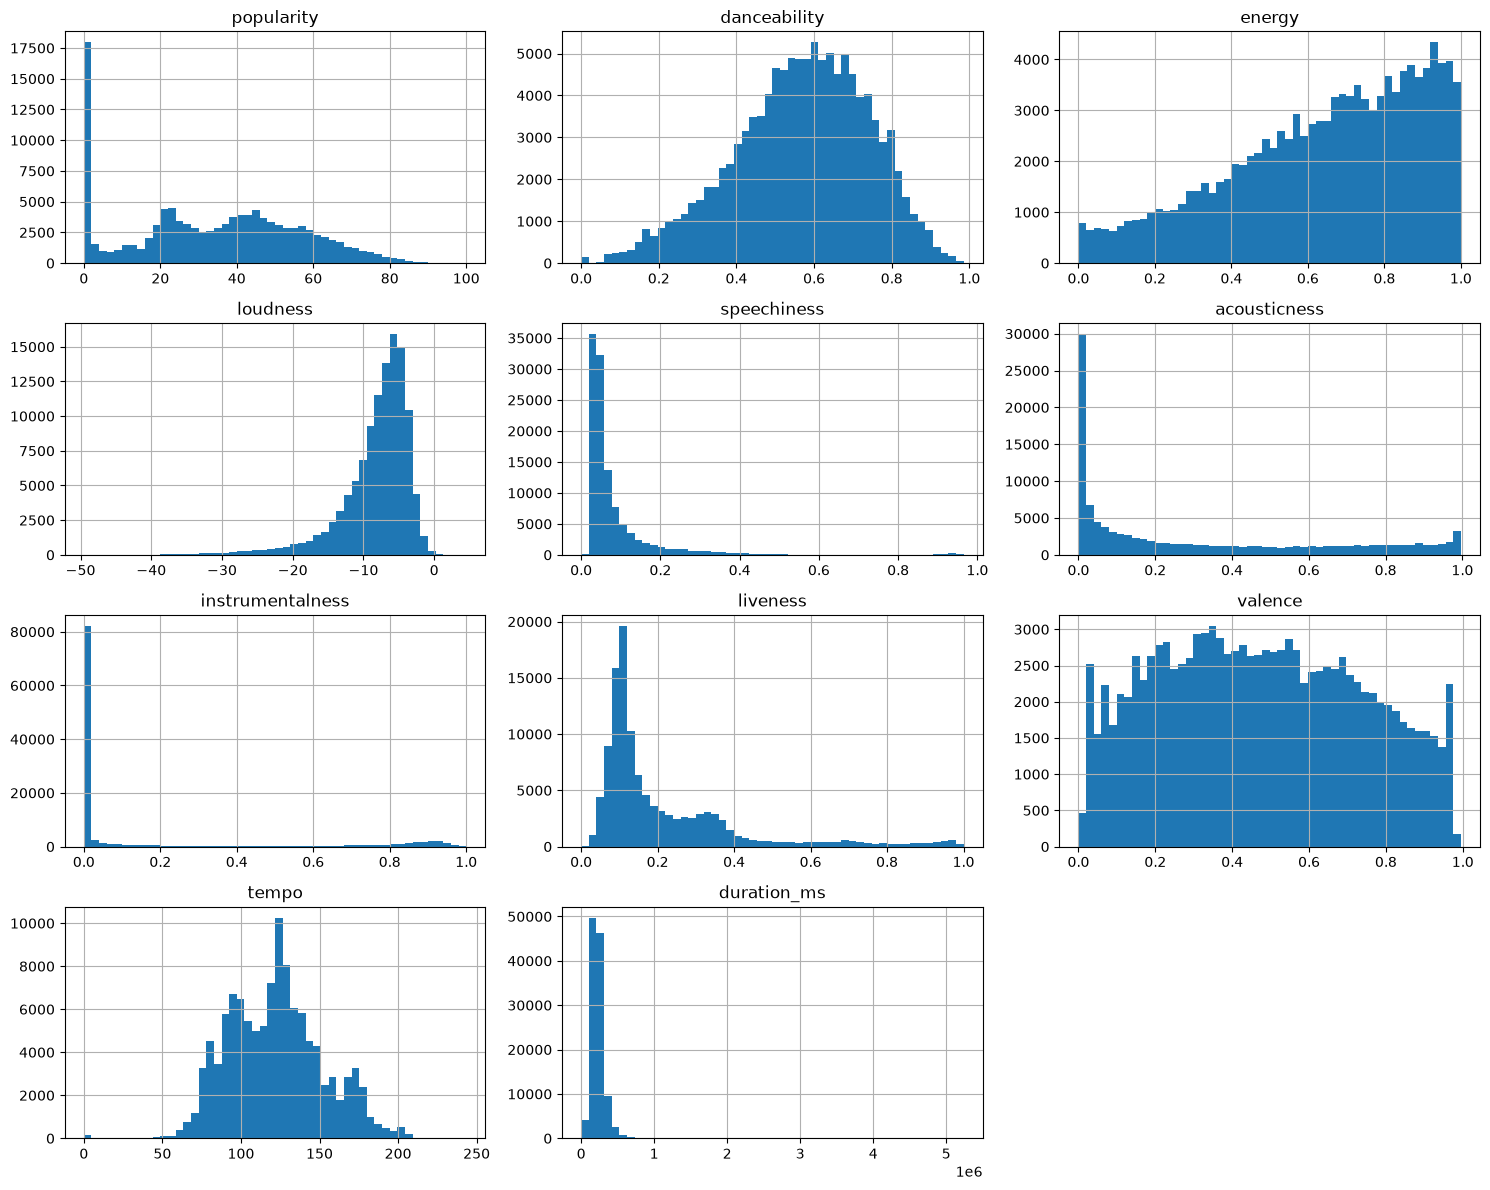

In [12]:
spotify_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]
df[spotify_features].hist(figsize=(15, 12), bins=50,)
plt.tight_layout()
plt.show()

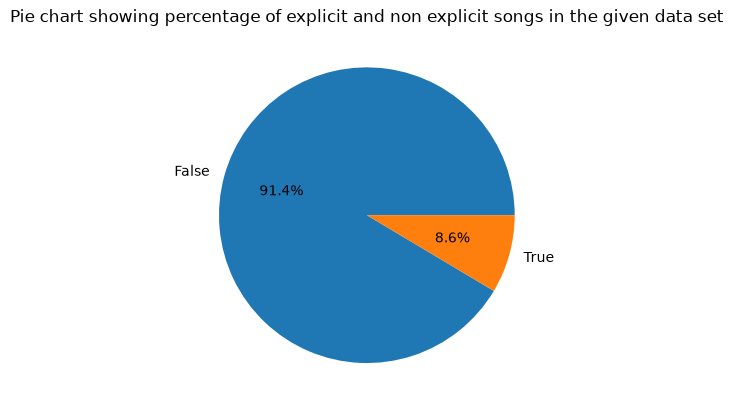

True = Explicit song
False = Not Explicit song


In [13]:
df.groupby("explicit")["popularity"].count().plot(kind="pie",autopct="%1.1f%%")
plt.title("Pie chart showing percentage of explicit and non explicit songs in the given data set")
plt.show()
print("True = Explicit song\nFalse = Not Explicit song")

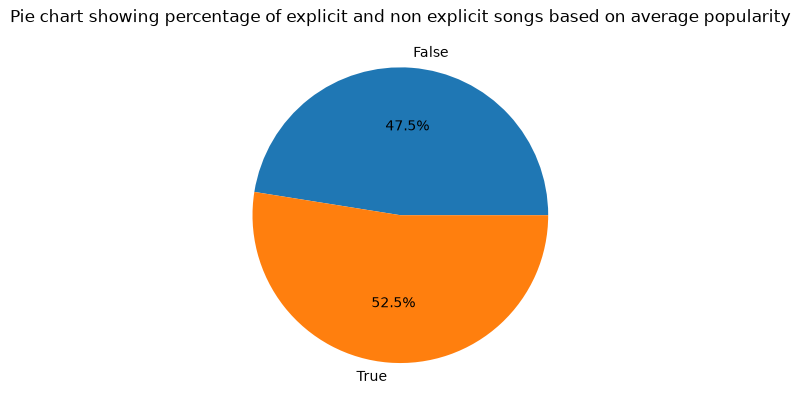

True = Explicit song
False = Not Explicit song


In [14]:
df.groupby("explicit")["popularity"].mean().plot(kind="pie",autopct="%1.1f%%")
plt.title("Pie chart showing percentage of explicit and non explicit songs based on average popularity")
plt.show()
print("True = Explicit song\nFalse = Not Explicit song")

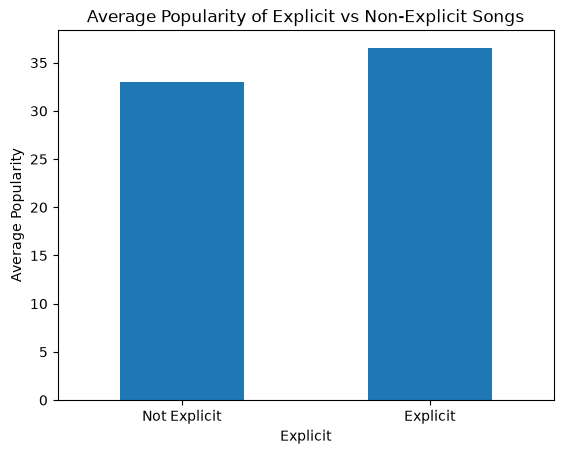

In [15]:
df.groupby("explicit")["popularity"].mean().plot(kind="bar")
plt.title("Average Popularity of Explicit vs Non-Explicit Songs")
plt.xlabel("Explicit")
plt.ylabel("Average Popularity")
plt.xticks([0, 1], ["Not Explicit", "Explicit"], rotation=0)
plt.show()

## Exploring relationships and correlations between different features.

In [16]:
df.corr(numeric_only=True)

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.000000,-0.007899,0.043941,0.034412,-0.002444,-0.004174,0.047371,-0.014991,-0.045459,-0.022370,-0.094711,-0.005658,-0.041109,0.012180,0.030564
duration_ms,-0.007899,1.000000,-0.065997,-0.074108,0.058163,0.008510,-0.004228,-0.035935,-0.063188,-0.103695,0.125307,0.010213,-0.154810,0.024301,0.018347
explicit,0.043941,-0.065997,1.000000,0.122180,0.096257,0.004842,0.107989,-0.037383,0.307456,-0.093751,-0.103168,0.032368,-0.003782,-0.003098,0.038234
danceability,0.034412,-0.074108,0.122180,1.000000,0.131695,0.036544,0.256559,-0.069778,0.108237,-0.169183,-0.183972,-0.131648,0.476750,-0.051518,0.207369
energy,-0.002444,0.058163,0.096257,0.131695,1.000000,0.048046,0.760624,-0.079328,0.141976,-0.732745,-0.179966,0.184812,0.258448,0.247360,0.186671
key,-0.004174,0.008510,0.004842,0.036544,0.048046,1.000000,0.038358,-0.135876,0.020819,-0.041119,-0.006821,-0.001521,0.034237,0.010905,0.015123
loudness,0.047371,-0.004228,0.107989,0.256559,0.760624,0.038358,1.000000,-0.042071,0.060088,-0.588110,-0.432108,0.076793,0.279424,0.212180,0.191648
mode,-0.014991,-0.035935,-0.037383,-0.069778,-0.079328,-0.135876,-0.042071,1.000000,-0.046770,0.096534,-0.050780,0.013909,0.021399,0.000364,-0.024367
speechiness,-0.045459,-0.063188,0.307456,0.108237,0.141976,0.020819,0.060088,-0.046770,1.000000,-0.001381,-0.089213,0.205092,0.036391,0.017166,-0.000398
acousticness,-0.022370,-0.103695,-0.093751,-0.169183,-0.732745,-0.041119,-0.588110,0.096534,-0.001381,1.000000,0.102129,-0.020321,-0.106228,-0.207613,-0.175618


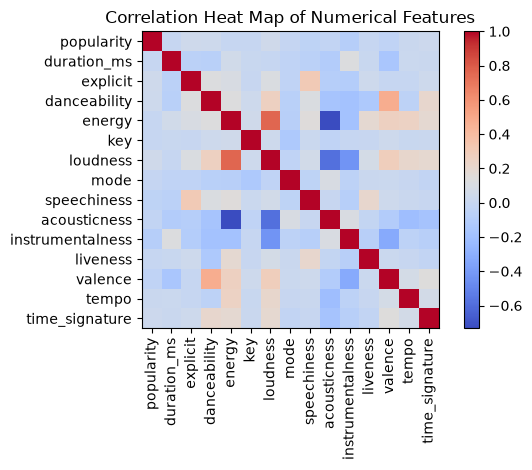

In [17]:
import matplotlib.pyplot as plt
correlation = df.corr(numeric_only=True)
plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Heat Map of Numerical Features")
plt.tight_layout()
plt.show()

## Using appropriate visualizations to identify trends, patterns, correlations, and potential outliers

In [18]:
# It is data of spotify so we tried to find features which play major role in popularity
popularity_affecting_features = df.corr(numeric_only=True)["popularity"].sort_values(ascending=False)
positive_feature = popularity_affecting_features.iloc[1:4]
negative_feature = popularity_affecting_features.iloc[-1:-4:-1]
# print(popularity_affecting_features)
print(f"List of numerical features having positive corelation with popularity : \n{positive_feature}\n")
print(f"List of numerical features having negative corelation with popularity : \n{negative_feature}")

List of numerical features having positive corelation with popularity : 
loudness        0.047371
explicit        0.043941
danceability    0.034412
Name: popularity, dtype: float64

List of numerical features having negative corelation with popularity : 
instrumentalness   -0.094711
speechiness        -0.045459
valence            -0.041109
Name: popularity, dtype: float64


The above correlation data show us that `popularity` factor is `not` that much dependent on any `other factors` as correlation values are very small

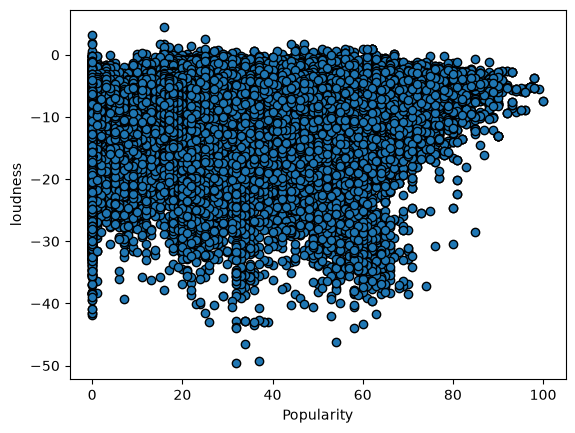

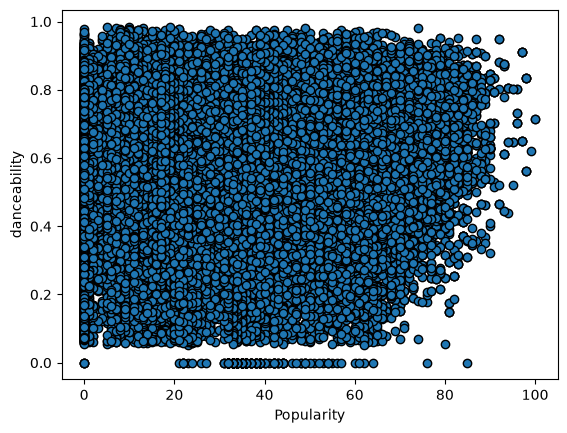

In [19]:
# Ploting graph to show that their is not much relation between these data
for i in ["loudness","danceability"]:
    plt.scatter(df["popularity"],df[i],edgecolors="black")
    plt.xlabel("Popularity")
    plt.ylabel(i)
    plt.show()


The scatter plots support the correlation analysis, showing that loudness and danceability have only weak linear relationships with popularity.

### Analysing track genre to know which track genres are more popular

List of Track genre based on average popularity : 
 track_genre
pop-film          59.28
k-pop             56.91
chill             53.70
sad               52.38
grunge            49.58
                  ...  
chicago-house     12.33
detroit-techno    11.18
latin              8.36
romance            3.55
iranian            2.22
Name: popularity, Length: 114, dtype: float64


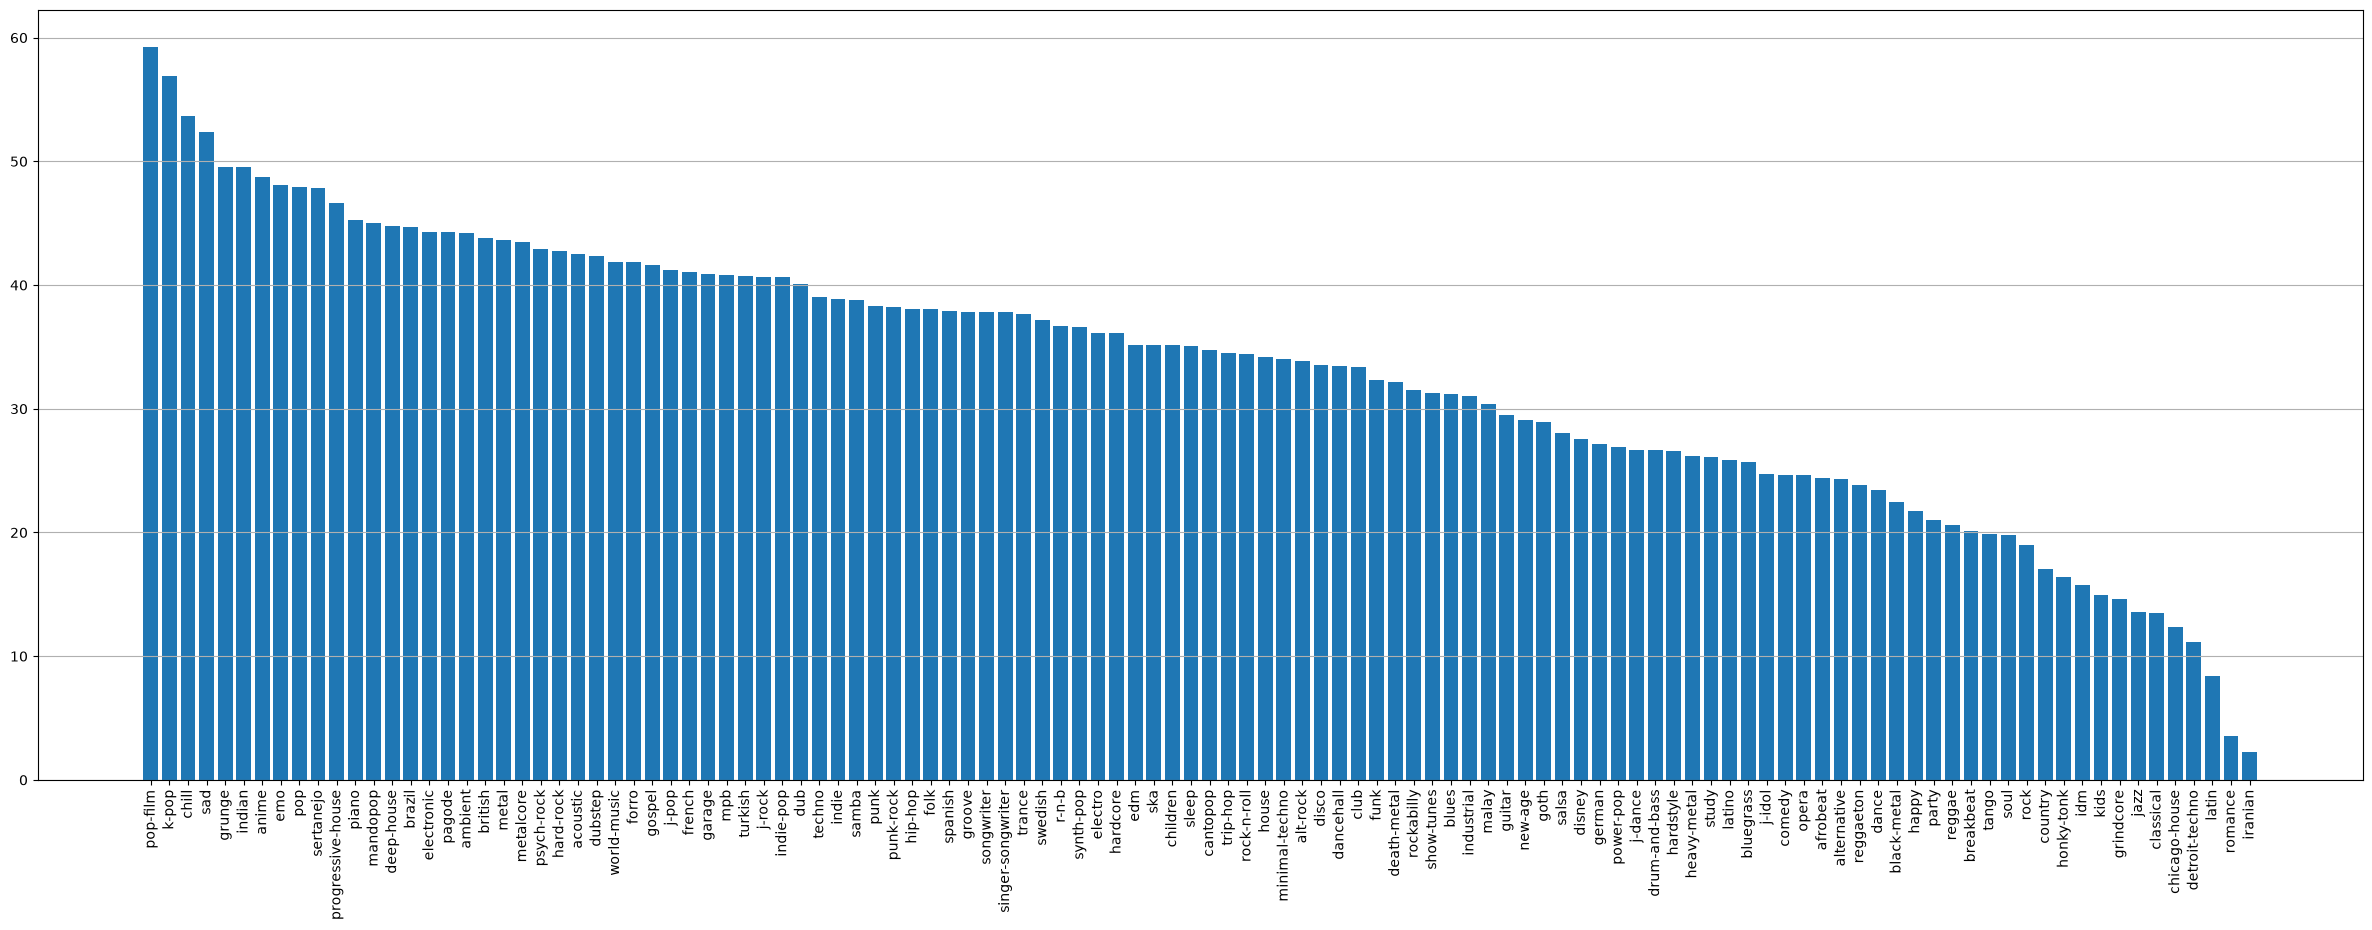

In [20]:
popularity_of_genre = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False)
print("List of Track genre based on average popularity : \n",popularity_of_genre.round(2))
plt.figure(figsize=(30,10))
plt.bar(popularity_of_genre.index,popularity_of_genre.values)
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

This graph shows the bar chart of popularity of different track genres.
This suggests that popularity varies considerably between genres.
As we can see their is quit a fluctuation in graph showing us that their are some genre which are highly popular and some which are very less popular.

### Finding Potential Outliers 

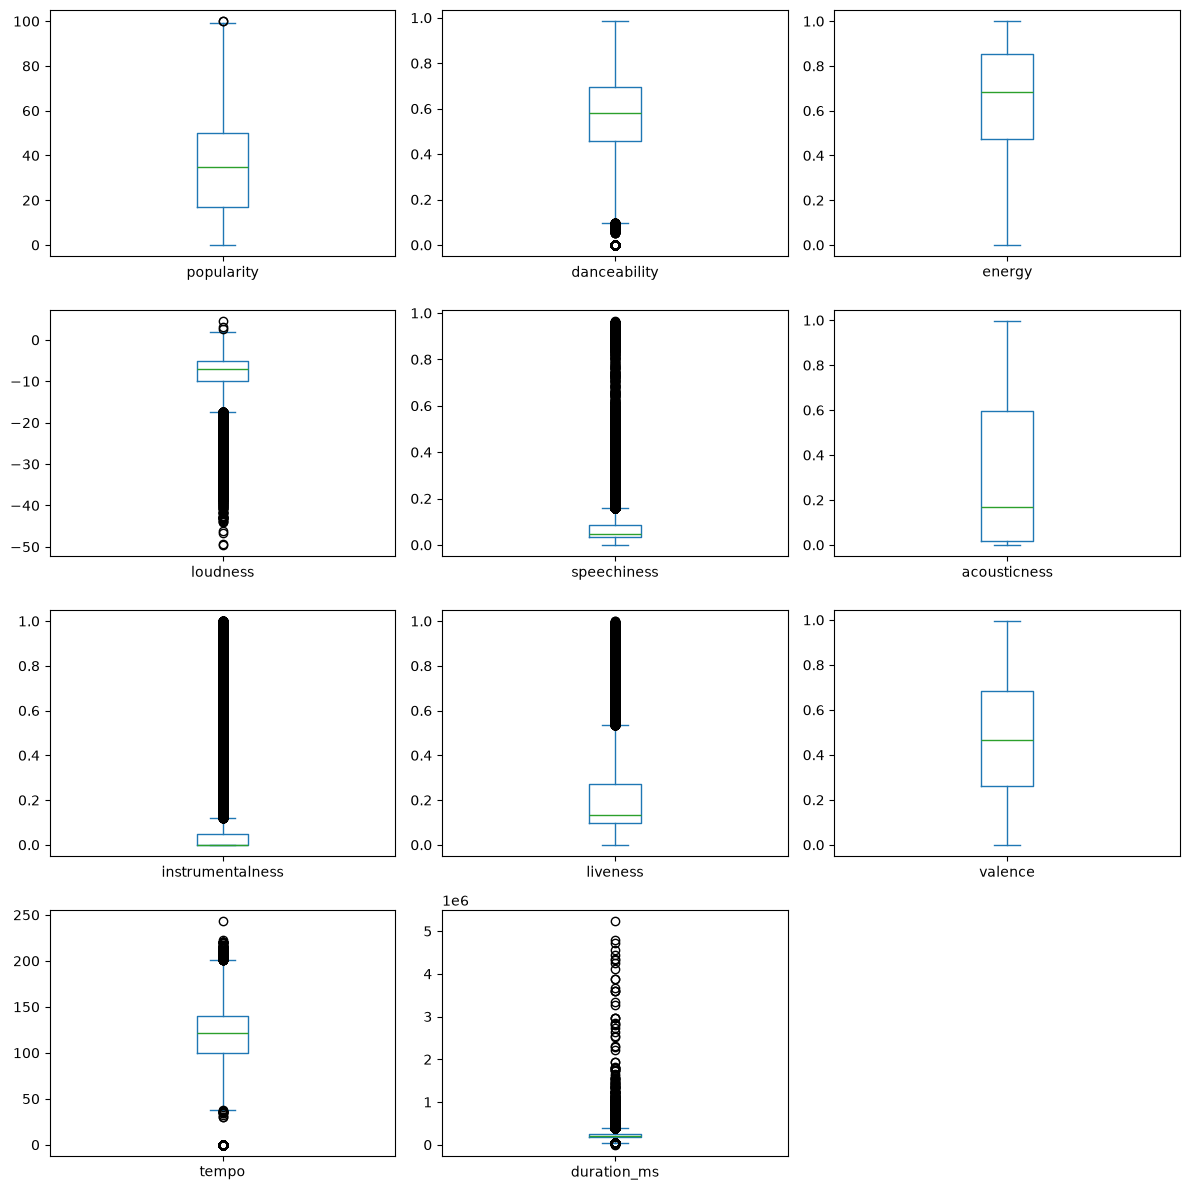

In [21]:
# Visuvalizing outliers in differnt spotify_features
df[spotify_features].plot(kind="box",subplots=True,layout=(4, 3),figsize=(12, 12))
plt.tight_layout()
plt.show()

The above boxplots show the outlier present in different features of spotify features

In [22]:
# Finding no. of outliers present in different features using IQR method
statical_data = df.describe()
iqr = statical_data.loc["75%"] - statical_data.loc["25%"]
lower_limit = statical_data.loc["25%"] - 1.5*iqr
upper_limit = statical_data.loc["75%"] + 1.5*iqr
df.describe()
iqr_df = pd.DataFrame()
iqr_df = pd.concat([lower_limit,upper_limit],axis=1)
iqr_df.columns = (["lower_limit","upper_limit"])
iqr_df
df["popularity"][( df["popularity"] >= iqr_df.loc["popularity","lower_limit"]) & (df["popularity"] <= iqr_df.loc["popularity","upper_limit"])].count()
for i in iqr_df.index:
    iqr_df.loc[i,"not_outlier_count"] = int(df[i][( df[i] >= iqr_df.loc[i,"lower_limit"]) & (df[i] <= iqr_df.loc[i,"upper_limit"])].count())
    iqr_df.loc[i,"oulier_count"] = len(df) - int(iqr_df.loc[i,"not_outlier_count"])
iqr_df.sort_values(by="oulier_count",ascending=False)

,lower_limit,upper_limit,not_outlier_count,oulier_count
instrumentalness,-0.073012,0.121687,88419.0,25131.0
speechiness,-0.037000,0.157400,100383.0,13167.0
time_signature,4.000000,4.000000,101487.0,12063.0
liveness,-0.164500,0.535500,104940.0,8610.0
loudness,-17.492875,2.494125,107435.0,6115.0
duration_ms,43069.000000,392699.000000,107957.0,5593.0
danceability,0.097500,1.053500,112935.0,615.0
tempo,38.130625,201.239625,112935.0,615.0
popularity,-32.500000,99.500000,113548.0,2.0
energy,-0.098500,1.425500,113550.0,0.0


The large number of potential outliers does not automatically mean the data is incorrect.
Musical characteristics naturally have unusual observations.

### Analysing different features based on popularity of artists

In [23]:
popularity_of_artist = df.groupby("artists")["popularity"].mean().sort_values(ascending=False)
df_artist = pd.DataFrame()
df_artist.index = popularity_of_artist.index
df_artist["popularity"] = popularity_of_artist.values
df_artist = pd.concat([df_artist,df.groupby("artists")["popularity"].count()],axis=1)
df_artist = pd.concat([df_artist,df.groupby("artists")[["danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]].mean()],axis=1)
df_artist.columns = ["average_popularity"
    ,"count",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"]
df_artist = df_artist.round(4)
df_artist.head(10)


,average_popularity,count,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
artists,,,,,,,,,,,,
Sam Smith;Kim Petras,100.0,2,0.7140,0.4720,-7.3750,0.0864,0.0130,0.0000,0.2660,0.238,131.121,156943.0000
Bizarrap;Quevedo,99.0,1,0.6210,0.7820,-5.5480,0.0440,0.0125,0.0330,0.2300,0.550,128.033,198937.0000
Manuel Turizo,98.0,4,0.8350,0.6790,-5.3290,0.0364,0.5830,0.0000,0.2180,0.850,124.980,162637.0000
Bad Bunny;Chencho Corleone,97.0,4,0.9110,0.7120,-5.1050,0.0817,0.0901,0.0000,0.0933,0.425,92.005,178567.0000
Bad Bunny;Bomba Estéreo,94.5,4,0.6470,0.6860,-5.7450,0.0413,0.0800,0.0000,0.5280,0.268,79.928,258298.0000
Joji,94.0,1,0.4400,0.3170,-9.2580,0.0531,0.8910,0.0000,0.1410,0.268,169.914,233456.0000
Beyoncé,93.0,1,0.7800,0.6890,-5.6680,0.1410,0.0368,0.0000,0.0698,0.642,115.042,225388.0000
Harry Styles,92.0,3,0.5293,0.7593,-4.9617,0.0526,0.2687,0.0007,0.3190,0.627,147.750,169535.3333
Rema;Selena Gomez,92.0,1,0.8010,0.8060,-5.2060,0.0381,0.3820,0.0007,0.1140,0.802,106.999,239317.0000


This analysis identifies artists with the highest average popularity while also examining their number of songs and average audio features.

### Analysing different features based on popularity of track genre

In [24]:
# popularity_of_genre = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False)      we already created while analysing track genre
df_track_genre = pd.DataFrame()
df_track_genre.index = popularity_of_genre.index
df_track_genre["popularity"] = popularity_of_genre.values
df_track_genre = pd.concat([df_track_genre,df.groupby("track_genre")["popularity"].count()],axis=1)
df_track_genre = pd.concat([df_track_genre,df.groupby("track_genre")[["danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]].mean()],axis=1)
df_track_genre.columns = ["average_popularity"
    ,"count",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"]
df_track_genre = df_track_genre.round(4)
df_track_genre.head(10)


,average_popularity,count,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
track_genre,,,,,,,,,,,,
pop-film,59.2803,999,0.5973,0.6044,-7.8736,0.0641,0.4408,0.0081,0.1664,0.5290,117.2910,279622.1842
k-pop,56.9069,999,0.6476,0.6758,-6.4679,0.0879,0.2924,0.0098,0.1764,0.5567,119.2507,251460.4244
chill,53.7047,999,0.6642,0.4264,-10.4668,0.1022,0.5346,0.1782,0.1683,0.4035,115.4889,169042.9520
sad,52.3790,1000,0.6924,0.4625,-10.2750,0.1304,0.4737,0.1057,0.1716,0.4220,119.0650,153800.8800
grunge,49.5826,999,0.4571,0.8031,-5.6616,0.0611,0.0535,0.0370,0.2223,0.4004,129.3379,235583.3914
indian,49.5285,999,0.5924,0.5671,-8.8484,0.0721,0.4852,0.0394,0.1730,0.4633,116.1391,245539.6186
anime,48.7668,999,0.5375,0.6738,-7.9384,0.0873,0.2680,0.2632,0.1973,0.4346,123.5497,210159.1552
emo,48.1280,1000,0.5993,0.6700,-6.7186,0.1090,0.1951,0.0303,0.1837,0.4411,126.9926,189690.3300
pop,47.9033,993,0.6304,0.6055,-6.9707,0.0802,0.3458,0.0091,0.1580,0.5069,120.8814,220724.8359


This analysis identifies genres with the highest average popularity while also examining their number of songs and average audio features.

## Meaningful Insights from the Spotify Dataset

* The dataset contains songs from a wide variety of artists and musical genres.
* Song popularity varies considerably across different genres.
* Some genres are generally associated with higher popularity, while others have lower average popularity.
* The number of songs associated with an artist does not necessarily indicate that the artist has higher popularity.
* Popular songs tend to show differences in audio characteristics such as danceability, energy, loudness, acousticness, and instrumentalness.
* No single numerical audio feature has a strong relationship with song popularity.
* Explicit and non-explicit songs show differences in their popularity distribution.
* Several audio features contain potential outliers, but these values may represent genuine differences in musical characteristics rather than errors.
* The analysis suggests that song popularity is influenced by multiple factors rather than one particular musical feature.
* Overall, the dataset demonstrates that artist, genre, explicit content, and audio characteristics can all provide useful insights into patterns of song popularity.
